# Target Leakage Audit

**Goal**:  Identify & eliminate information leakage that would inflate model performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
df = pd.read_parquet('../data/generated/sales_data.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min()} - {df['date'].max()}")
print(f"Total Rows: {len(df)}")
print(f"Unique Stores: {df['store_id'].nunique()}")
print(f"Unique Products: {df['product'].nunique()}")
print(f"Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()} total")

print("=========================================")
print(df.head())

Dataset Shape: (2883231, 55)
Date Range: 2016-01-01 00:00:00 - 2026-08-26 00:00:00
Total Rows: 2883231
Unique Stores: 37
Unique Products: 27
Columns: 55
Missing Values: 0 total
        date       region    city       store  store_id  \
0 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
1 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
2 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
3 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
4 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   

                 product    brand     category  price  discount  ...  \
0  Samsung Electronics 1  Samsung  Electronics  29429        10  ...   
1  Samsung Electronics 2  Samsung  Electronics  46485         5  ...   
2  Samsung Electronics 3  Samsung  Electronics  27684         0  ...   
3     Sony Electronics 2     Sony  Electronics  57529         5  ...   
4       LG Electronics 1       LG  Electronics  32991        10  ...   

   salary_week_flag  supplier_lead_

## 2. Define Target & Prediction Boundary

In [3]:
TARGET = 'demand'

# Split data
train_pct = 0.9
split_date = df['date'].quantile(train_pct)

train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"TARGET VARIABLE: {TARGET}")
print(f"\n Train/Test Split:")
print(f"Train: {train_df['date'].min()} -> {train_df['date'].max()} ({len(train_df):,}) rows")
print(f"Test: {test_df['date'].min()} -> {test_df['date'].max()} ({len(train_df):,}) rows")
print(f"Train %: {len(train_df) / len(df) * 100:.1f}%")
print(f"Test %: {len(test_df)/ len(df) * 100:.1f} %")

TARGET VARIABLE: demand

 Train/Test Split:
Train: 2016-01-01 00:00:00 -> 2025-08-01 00:00:00 (2,594,241) rows
Test: 2025-08-02 00:00:00 -> 2026-08-26 00:00:00 (2,594,241) rows
Train %: 90.0%
Test %: 10.0 %


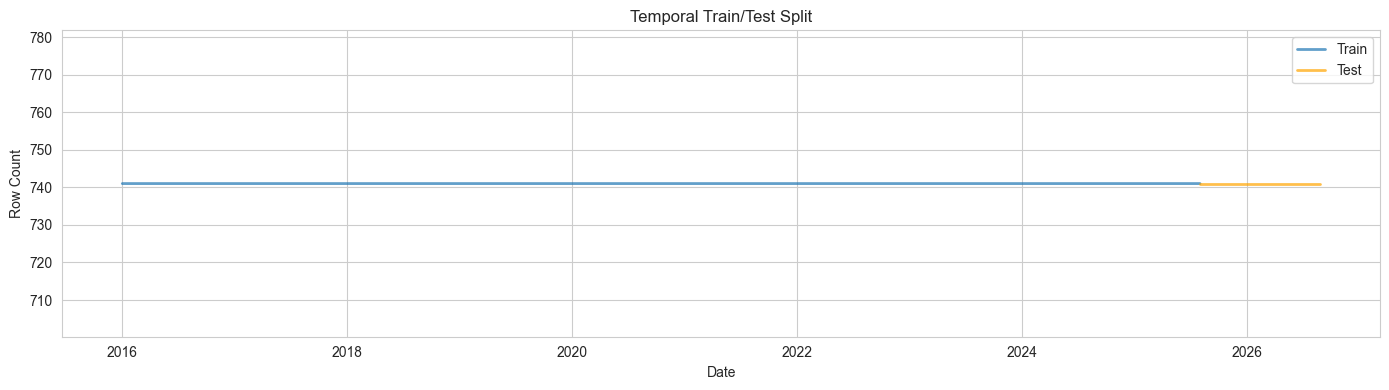

In [4]:
# Visualize temporal split
plt.figure(figsize = (14, 4))
train_dates = train_df.groupby('date').size()
test_dates = test_df.groupby('date').size()

plt.plot(train_dates.index, train_dates.values, label = 'Train', linewidth = 2, alpha = 0.7)
plt.plot(test_dates.index, test_dates.values, label = 'Test', linewidth = 2, alpha = 0.7, color = 'orange')
plt.xlabel('Date')
plt.ylabel('Row Count')
plt.title('Temporal Train/Test Split')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Check Date Contamination

In [5]:
# AUDIT: Do train & test dates overlap?
train_min, train_max = train_df['date'].min(), train_df['date'].max()
test_min, test_max = test_df['date'].min(), test_df['date'].max()

print("CHECK #1: Date Contamination")
print(f"="*60)

if train_max >= test_min:
    print(f"FAIL: Train max ({train_max.date()}) >= Test min({test_min.date()})")
    print(f"Overlap period: {test_min.date()} to {train_max.date()}")
    overlapping_rows = len(df[(df['date'] >= test_min) & (df['date'] <= train_max)])
    print(f"Contaminated rows: {overlapping_rows}")
    data_leakage = True
else:
    print(f"PASS: Clean temporal split")
    print(f"Train ends: {train_max.date()}")
    print(f"Test Starts: {test_min.date()}")
    data_leakage = False

print(f"\nGap between train & test: {(test_min -  train_max).days} days")

CHECK #1: Date Contamination
PASS: Clean temporal split
Train ends: 2025-08-01
Test Starts: 2025-08-02

Gap between train & test: 1 days


## 4. Check for Outcome-Dependent Features

In [6]:
outcome_dependent = ['sales', 'sales_qty', 'lost_sales']

print("CHECK 2: Outcome Dependent Features")
print(f"=" * 60)
print(f"TARGET: {TARGET}")
print(f"\n Dangeous Columns (depend on target):")

risky_features = []
for col in outcome_dependent:
    if col in df.columns and col != TARGET:
        print(f"\n ❌️ {col}")
        print(f"Why: {col} is calculated from/with {TARGET}")
        if col == 'sales':
            print(f"Formula: sales_qty * final_price")
        elif col == 'lost_sales':
            print("Formula: max(0, demand - inventory)")
        print(f"ACTION: REMOVE before modelling")
        risky_features.append(col)
    
if not risky_features:
    print("✅️ PASS: No outcome-dependent features detected")

outcome_leakage = len(risky_features) >0

CHECK 2: Outcome Dependent Features
TARGET: demand

 Dangeous Columns (depend on target):

 ❌️ sales
Why: sales is calculated from/with demand
Formula: sales_qty * final_price
ACTION: REMOVE before modelling

 ❌️ sales_qty
Why: sales_qty is calculated from/with demand
ACTION: REMOVE before modelling

 ❌️ lost_sales
Why: lost_sales is calculated from/with demand
Formula: max(0, demand - inventory)
ACTION: REMOVE before modelling


## 5. Check for Future Information

In [7]:
print(f"CHECK 3: Future Information")
print(f"="*60)

future_keywords = ['tomorrow', 'next_', 'future', '_forecast', 'predicted_', 'ahead']
future_features = []

for col in df.columns:
    if any(kw in col.lower() for kw in future_keywords):
        future_keywords.append(col)
        print(f"❌️ {col}")
        print(f"Contains future information")
        print("ACTION: Use lagged/historical version\n")

if not future_features:
    print("✅️ PASS: No future information detected")
    future_leakage = False
else:
    print(f"\n Found {len(future_features)} future-looking features")
    future_leakage = True

CHECK 3: Future Information
✅️ PASS: No future information detected


## 6. Check for Global Statistics Contamination

In [8]:
print(f"CHECK 4: Global Statistics Contamination")
print(f"="*60)

static_feature_examples = ['avg_basket_size', 'foot_traffic_index', 'population_density']

print("Features that need TRAIN-ONLY Calculation:\n")

global_stats_issues = []
for col in static_feature_examples:
    if col in df.columns:
        # These should be static
        train_stats = train_df.groupby('store_id')[col].nunique()
        has_variation = (train_stats > 1).any()

        if not has_variation:
            print(f"✅️ {col}: Static (SAFE)")
        else:
            print(f"⚠️ {col}: TIME-VARYING (needs historical average)")
            global_stats_issues.append(col)

print(f"\n ACTION: Before prediction, recalculate all store/city attributes using TRAIN data only:")
print(f"\n Example (Don't Do This):")
print(f" >>> avg_basket = df.groupby('store_id)['avg_basket_size].mean() # WRONG - includes test")
print(f"\n Example (DO THIS):")
print(f" >>> avg_basket = train_df.groupby('store_id')['avg_basket_size].mean() # OK - train only")

global_stats_leakage = len(global_stats_issues) >0

CHECK 4: Global Statistics Contamination
Features that need TRAIN-ONLY Calculation:

✅️ avg_basket_size: Static (SAFE)
✅️ foot_traffic_index: Static (SAFE)
✅️ population_density: Static (SAFE)

 ACTION: Before prediction, recalculate all store/city attributes using TRAIN data only:

 Example (Don't Do This):
 >>> avg_basket = df.groupby('store_id)['avg_basket_size].mean() # WRONG - includes test

 Example (DO THIS):
 >>> avg_basket = train_df.groupby('store_id')['avg_basket_size].mean() # OK - train only


## 7. Check for Endogenous Variables

In [9]:
print("CHECK 5: Endogenous Variables")
print(f"=" * 60)

# Variables that are influenced by the target
endogenous_candidates = {
    'marketing_spend': 'Is marketing spend decided BEFORE or AFTER demand forecast?',
    'is_promo_campaign': 'Are promos decided becased on expected demand?',
    'discount': 'Is discount adjusted based on demand?',
    'inventory': 'Is inventory ordered based on demand forecast?'
}

endogenous_issues = []

for col, question in endogenous_candidates.items():
    if col in df.columns:
        print(f"\n {col}")
        print(f"Q: {question}")

        # Correlation with Target
        corr = df[col].corr(df[TARGET])
        print(f"Corr with {TARGET} : {corr:.3f}")

        if abs(corr) > 0.3:
            print(f"SUSPICIOUS: Strong Correlation")
            print(f"Action: Use historical/Lagged Version")
            endogenous_issues.append(col)
        else:
            print(f"Weak correlation (likely safe)")

endogenous_leakage = len(endogenous_issues) > 0

CHECK 5: Endogenous Variables

 marketing_spend
Q: Is marketing spend decided BEFORE or AFTER demand forecast?
Corr with demand : 0.037
Weak correlation (likely safe)

 is_promo_campaign
Q: Are promos decided becased on expected demand?
Corr with demand : 0.044
Weak correlation (likely safe)

 discount
Q: Is discount adjusted based on demand?
Corr with demand : 0.000
Weak correlation (likely safe)

 inventory
Q: Is inventory ordered based on demand forecast?
Corr with demand : 0.972
SUSPICIOUS: Strong Correlation
Action: Use historical/Lagged Version


## 8. Feature Availability at Prediction Time

In [10]:
print(f"CHECK 6: Feature Availability at Prediction Time")
print(f"=" * 60)

# When you make a forecast for day T, what info do you have?
print(f"\nScenario: Forecasting {TARGET} for date T")
print(f"Available at time T: Information from dates < T")
print(f"NOT available: Information from dates >= T\n")

feature_categories = {
    'ALWAYS SAFE': [
        'store_size_sqft (static)',
        'store_id, store, city, region (static)',
        'in_mall, parking_available, store_age_years (static)',
        'foot_traffic_index, population_density (static)',
        'is_weekend, is_month_start, salary_week_flag (calendar-derived)',
        'competitor_price_index (market_data)',
    ],
    'NEEDS CARE': [
        'temperature, rainfall_mm (use historical/forecasted)',
        'is_promo_campaign (use lagged)',
        'discount (use historical)',
        'marketing_spend (if endogenous)',
    ],
    'REMOVE': [
        'sales, sales_qty (outcome)',
        'lost_sales (outcome)',
        'inventory (may be endogenous)',
        'final_price (derived from outcome)',
    ]
}

for category, features in feature_categories.items():
    print(f"\n{category}:")
    for feat in features:
        print(f" * {feat}")

CHECK 6: Feature Availability at Prediction Time

Scenario: Forecasting demand for date T
Available at time T: Information from dates < T
NOT available: Information from dates >= T


ALWAYS SAFE:
 * store_size_sqft (static)
 * store_id, store, city, region (static)
 * in_mall, parking_available, store_age_years (static)
 * foot_traffic_index, population_density (static)
 * is_weekend, is_month_start, salary_week_flag (calendar-derived)
 * competitor_price_index (market_data)

NEEDS CARE:
 * temperature, rainfall_mm (use historical/forecasted)
 * is_promo_campaign (use lagged)
 * discount (use historical)
 * marketing_spend (if endogenous)

REMOVE:
 * sales, sales_qty (outcome)
 * lost_sales (outcome)
 * inventory (may be endogenous)
 * final_price (derived from outcome)


## 9. Suspicious Correlation Patterns

In [12]:
print(f"CHECK 7: Suspicious Correlations with Target")
print(f"=" * 60)

# Numeric columns
numeric_cols = df.select_dtypes(include = [np.number]).columns

# Correlations with Target
correlations = df[numeric_cols].corr()[TARGET].sort_values(ascending = False)

print(f"\nCorrelations with '{TARGET}': \n")
print(correlations)

CHECK 7: Suspicious Correlations with Target

Correlations with 'demand': 

demand                      1.000000
sales_qty                   0.996879
inventory                   0.972351
weather_demand_mod          0.467652
lost_sales                  0.349293
foot_traffic_index          0.297403
festival_intensity_score    0.286584
population_density          0.284329
is_holiday                  0.270054
festival_boost              0.257081
holiday_boost               0.244492
mall_count                  0.231766
is_metro                    0.208587
in_mall                     0.207740
gdp_per_capita              0.195336
premium_store_flag          0.185350
year_factor                 0.153258
store_size_sqft             0.150287
parking_available           0.089164
is_weekend                  0.080078
weekend_boost               0.080078
local_competitor_count      0.074865
student_area_flag           0.058046
store_age_years             0.056340
avg_basket_size             0.052421

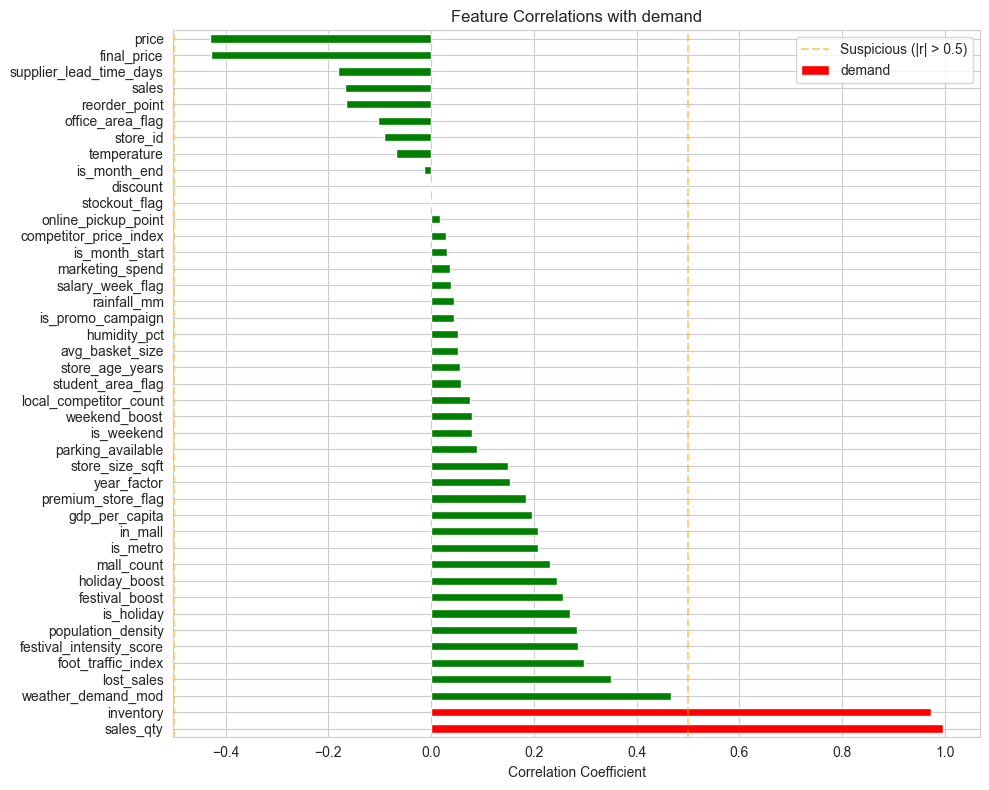

In [13]:
# Visualize
fig, ax = plt.subplots(figsize = (10, 8))
correlations.drop(TARGET).plot(kind = 'barh', ax = ax, color = ['red' if abs(x) > 0.5 else 'green' for x in correlations.drop(TARGET).values])
plt.xlabel('Correlation Coefficient')
plt.title(f"Feature Correlations with {TARGET}")
plt.axvline(0.5, color = 'orange', linestyle = '--', alpha = 0.5, label = 'Suspicious (|r| > 0.5)')
plt.axvline(-0.5, color = 'orange', linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
suspicious_corrs = [(col, corr) for col, corr in correlations.items()
if abs(corr) > 0.5 and col != TARGET]

if suspicious_corrs:
    print(f"\n⚠️ SUSPICIOUS (|correlation| > 0.5):")
    for col, corr in suspicious_corrs:
        print(f"*{col}: {corr:.3f} (investigate for leakage)")


⚠️ SUSPICIOUS (|correlation| > 0.5):
*sales_qty: 0.997 (investigate for leakage)
*inventory: 0.972 (investigate for leakage)


## 10. Generate Audit Report

In [16]:
print("\n\n" + "="*70)
print("LEAKAGE REPORT")
print("=" * 70)

# Risk scoring
critical_risks = 0
medium_risks = 0

findings = []

if data_leakage:
    critical_risks += 1
    findings.append("❌️ CRITICAL: Date Contamination - train & test overlap")
else:
    findings.append("✅️ PASS: Clean temporal split")

if outcome_leakage:
    critical_risks += 1
    findings.append(f"❌️ CRITICAL: {len(risky_features)} outcome-dependent features detected")
else:
    findings.append("✅️ PASS: No outcome-dependent features")

if future_leakage:
    critical_risks += 1
    findings.append(f"❌️ CRITICAL: {len(future_features)} future-information features detected")
else:
    findings.append("✅️ PASS: No future information")

if global_stats_leakage:
    medium_risks += 1
    findings.append(f"⚠️ MEDIUM: {len(global_stats_leakage)} time-varying static features")
else:
    findings.append("✅️ PASS: Global statistics handled correctly")

if endogenous_leakage:
    medium_risks += 1
    findings.append(f"⚠️ MEDIUM: {len(endogenous_issues)} potentially endogenous variables")
else:
    findings.append("✅️ PASS: No obvious endogenous variables")

for finding in findings:
    print(f"\n{finding}")

print(f"\n" + "="*70)
print(f"\n 📊 RISK SUMMARY:")
print(f" 🔴 CRITICAL: {critical_risks}")
print(f" 🟡 Medium: {medium_risks}")

if critical_risks == 0:
    print(f"\n✅️ ✅️ ✅️ YOUR DATA IS CLEAN - SAFE TO PROCEED TO MODELLING ✅️ ✅️ ✅️")
elif critical_risks > 0:
    print(f"\n ❌️ ❌️ ❌️ STOP - FIX CRITICAL RISKS BEFORE MODELLING ❌️ ❌️ ❌️")



LEAKAGE REPORT

✅️ PASS: Clean temporal split

❌️ CRITICAL: 3 outcome-dependent features detected

✅️ PASS: No future information

✅️ PASS: Global statistics handled correctly

⚠️ MEDIUM: 1 potentially endogenous variables


 📊 RISK SUMMARY:
 🔴 CRITICAL: 1
 🟡 Medium: 1

 ❌️ ❌️ ❌️ STOP - FIX CRITICAL RISKS BEFORE MODELLING ❌️ ❌️ ❌️


## 11. Export Safe Feature List

In [19]:
print("\n BUILDING SAFE FEATURE LIST")
print(f"=" * 60)

# Features to remove
remove_features = ['sales', 'sales_qty', 'lost_sales', 'final_price'] + risky_features + future_features
remove_features = list(set(remove_features)) # unique

# Features to keep
safe_features = [col for col in df.columns if col not in remove_features and col != TARGET]

print(f"\n ❌️ REMOVE ({len(remove_features)}):")
for i, feat in enumerate(remove_features, 1):
    print(f" {i}. {feat}")

# Save lists
pd.DataFrame({
    'feature': safe_features,
    'recommendation': ['KEEP'] * len(safe_features)
}).to_csv('safe_features.csv', index = False)

pd.DataFrame({
    'feature': remove_features,
    'recommendation': ['REMOVE'] * len(remove_features)
}).to_csv('remove_features.csv', index = False)

print(f"\n Saved to:")
print(f" -> notebooks/safe_features.csv")
print(f" -> notebooks/remove_features.csv")


 BUILDING SAFE FEATURE LIST

 ❌️ REMOVE (4):
 1. sales_qty
 2. sales
 3. lost_sales
 4. final_price

 Saved to:
 -> notebooks/safe_features.csv
 -> notebooks/remove_features.csv
